# Test ispezione, raffinamento e marcatura

Workflow:
1. import del modulo;
2. inizializzazione ZED/robot;
3. ispezione globale;
4. raffinamento;
5. marcatura controllata;

## 1 — Import del modulo

Questa cella importa `inspection_and_marking.py`.

`importlib.reload(im)` serve per ricaricare il file `.py` se lo modifichi in VSCode durante la sessione notebook.

**Nota:** dopo `reload`, i parametri tornano ai valori scritti nel file `.py`, quindi la cella successiva li risetta per il tuning.

In [1]:
import importlib
import numpy as np
import time
import matplotlib.pyplot as plt

import inspection_and_marking as im
import Variables as vb

im = importlib.reload(im)

print("Modulo inspection_and_marking importato e ricaricato.")

Modulo inspection_and_marking importato e ricaricato.


## 2 — Inizializzazione robot + ZED

**Attenzione: muove il robot** verso la posizione iniziale.

In [2]:
# Se non hai già inizializzato la ZED nella cella precedente, lascia questa parte attiva.
if "zed" not in globals():
    zed, runtime, image_zed, point_cloud = im.init_zed()
    print("ZED inizializzata.")
else:
    print("ZED già inizializzata.")

ZED inizializzata.


In [3]:
controller = im.RobotController(
    ip_address=im.IP_ROBOT,
    default_position_j=vb.LOOK_DOWN_POSITION_J_INIZIO
)

controller.connect()
print("Robot connesso.")

[17:28:55] INFO     Succesfully connected to robot Ethernet Slave and Modbus.                         techman.py:25

           INFO     Connected to Listen Node                                                          techman.py:37

Robot connesso.


In [4]:
# posizionamento iniziale
controller.default_positioning()
print("Robot in posizione iniziale.")

im.move_to_hub(controller)

Robot in posizione iniziale.
Ritorno alla posizione di hub [0, 0, 90].
  [CIRCLE] Movimento sferico: (1.9°, 124.6°) -> (0.0°, 90.0°)


In [5]:
# Switch per attivare/disattivare l'identificazione dei difetti generici
im.GENERIC_DETECTION = True

print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")

if im.GENERIC_DETECTION:
    print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")
    im.GLOBAL_ATTENTION_RADIUS = 400 # Tuning: con detection generica serve un po' di attenzione per evitare falsi positivi ai bordi.
else:
    print("Rilevamento generico dei difetti disattivato.")
    im.GLOBAL_ATTENTION_RADIUS = None

Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius
Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius


## 3 — Ispezione globale completa

**Attenzione: muove il robot.**

=== ISPEZIONE GLOBALE ===
Numero posizioni di ispezione: 5
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).

------------------------------------------------------------
Scatto 1/5
Posizione sferica: [300, 0, 90]
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti trovati in questo scatto: 2
      Scatto 1 - difetto 1 rilevato:
        centroid: [827 546]
        pos3d_camera: [ 46.8  41.4 164.9]
        Z camera: 164.9 mm
        radial camera: 62.5 mm
        pos3d_global: [ 45.7 620.3 376.3]
        sph_coord [r, alpha, beta]: [148.9  19.1 106.1]
      Scatto 1 - difetto 2 rilevato:
        centroid: [552 366]
        pos3d_camera: [-13.7   0.8 148.7]
        Z camera: 148.7 mm
        radial camera: 13.7 mm
        pos3d_global: [-14.8 660.9 392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]


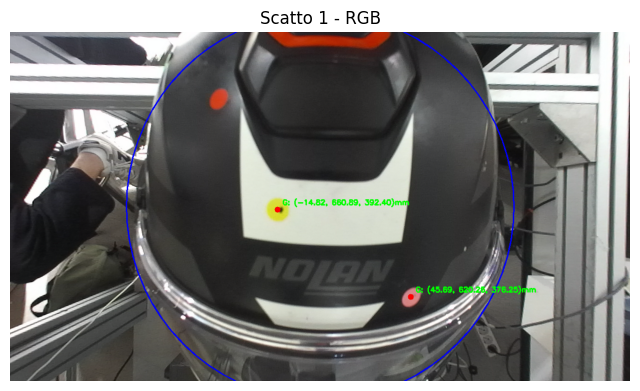

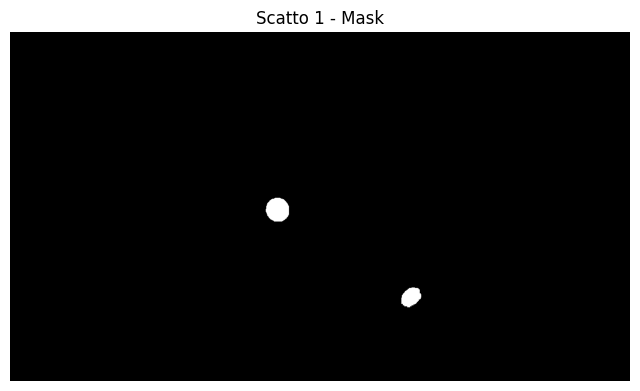


------------------------------------------------------------
Scatto 2/5
Posizione sferica: [300, 0, 45]
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (0.0°, 45.0°)
Difetti trovati in questo scatto: 1
      Scatto 2 - difetto 1 rilevato:
        centroid: [263 377]
        pos3d_camera: [-79.9   5.  167.6]
        Z camera: 167.6 mm
        radial camera: 80.1 mm
        pos3d_global: [-81.1 751.8 338.3]
        sph_coord [r, alpha, beta]: [154.8 -39.5  54.4]


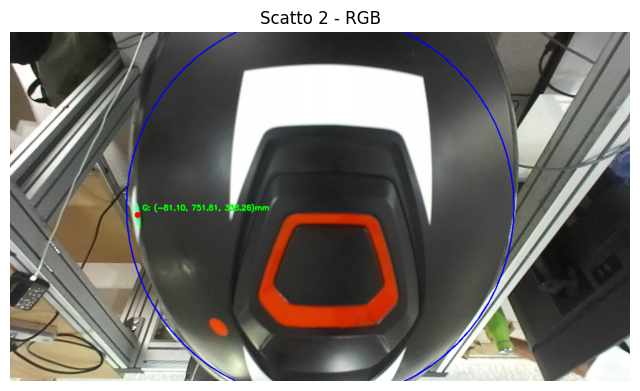

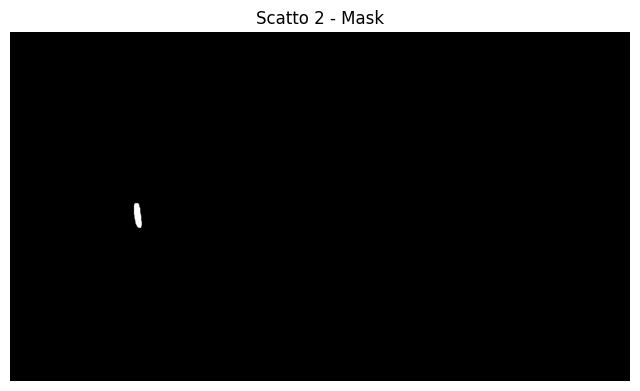


------------------------------------------------------------
Scatto 3/5
Posizione sferica: [300, 0, 30]
  [CIRCLE] Movimento sferico: (0.0°, 45.0°) -> (0.0°, 30.0°)
Difetti trovati in questo scatto: 2
      Scatto 3 - difetto 1 rilevato:
        centroid: [271 505]
        pos3d_camera: [-83.7  34.2 177.5]
        Z camera: 177.5 mm
        radial camera: 90.4 mm
        pos3d_global: [-84.8 750.6 331.9]
        sph_coord [r, alpha, beta]: [152.2 -42.7  54.2]
      Scatto 3 - difetto 2 rilevato:
        centroid: [738  12]
        pos3d_camera: [ 20.9 -61.2 128. ]
        Z camera: 128.0 mm
        radial camera: 64.6 mm
        pos3d_global: [ 19.7 841.2 274.1]
        sph_coord [r, alpha, beta]: [183.7  32.3  12.3]


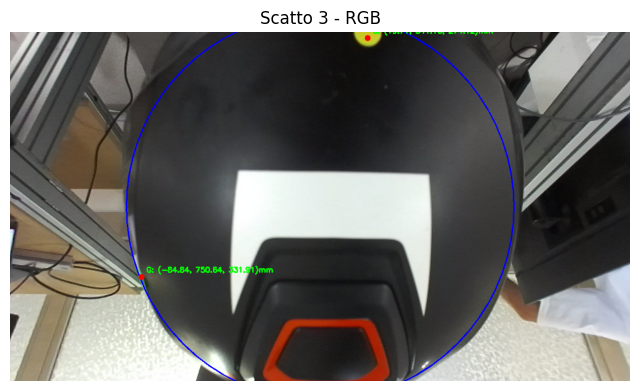

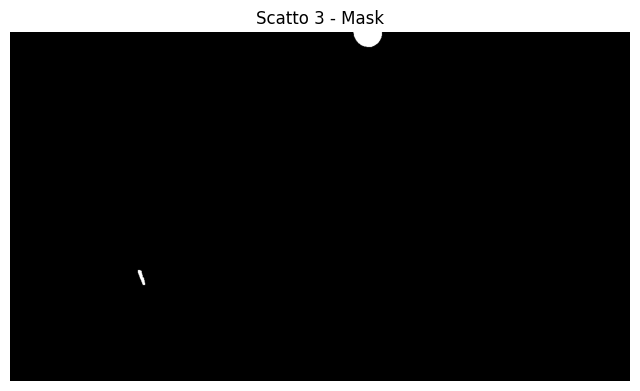


------------------------------------------------------------
Scatto 4/5
Posizione sferica: [300, 87, 60]
  [CIRCLE] Movimento sferico: (0.0°, 30.0°) -> (87.0°, 60.0°)
Difetti trovati in questo scatto: 2
      Scatto 4 - difetto 1 rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.2 144.1]
        Z camera: 144.1 mm
        radial camera: 46.8 mm
        pos3d_global: [116.7 765.7 283.1]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]
      Scatto 4 - difetto 2 rilevato:
        centroid: [860  77]
        pos3d_camera: [ 49.2 -58.  149.2]
        Z camera: 149.2 mm
        radial camera: 76.0 mm
        pos3d_global: [102.9 787.3 197.3]
        sph_coord [r, alpha, beta]: [168.9 112.8  41.9]


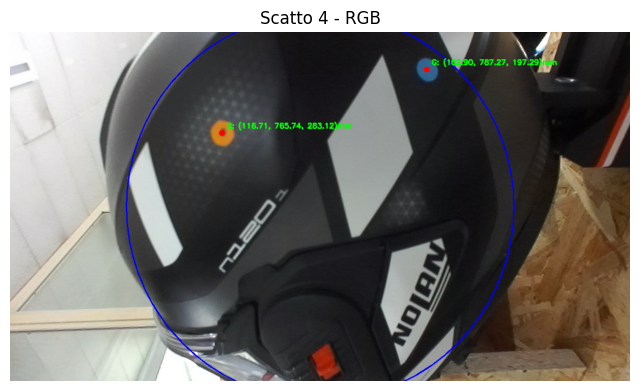

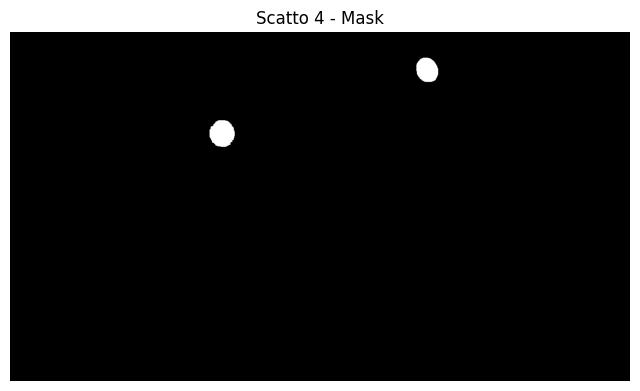


------------------------------------------------------------
Scatto 5/5
Posizione sferica: [300, -87, 60]
  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (87.0°, 60.0°) -> (0.0°, 60.0°)
  [CIRCLE] Movimento sferico: (0.0°, 60.0°) -> (-87.0°, 60.0°)
Difetti trovati in questo scatto: 3
      Scatto 5 - difetto 1 rilevato:
        centroid: [992 242]
        pos3d_camera: [ 86.9 -28.  170.9]
        Z camera: 170.9 mm
        radial camera: 91.3 mm
        pos3d_global: [-94.3 750.4 333. ]
        sph_coord [r, alpha, beta]: [158.2 -45.4  55.9]
      Scatto 5 - difetto 2 rilevato:
        centroid: [730 216]
        pos3d_camera: [ 22.7 -29.9 150.1]
        Z camera: 150.1 mm
        radial camera: 37.5 mm
        pos3d_global: [-114.7  762.5  269.8]
        sph_coord [r, alpha, beta]: [154.5 -75.8  49.3]
      Scatto 5 - difetto 3 rilevato:
        centroid: [452 133]
        pos3d_camera: [-35.4 -48.5 155.3]
        Z camera: 155.3 mm
  

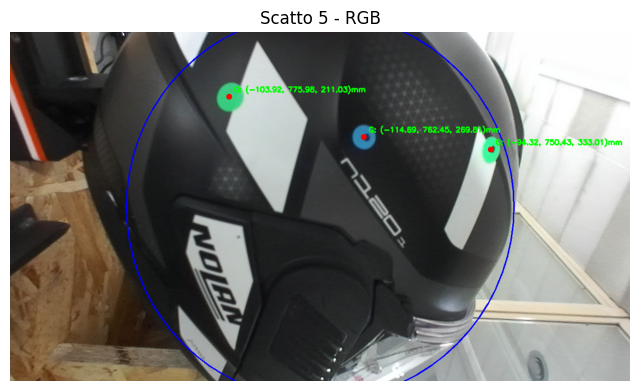

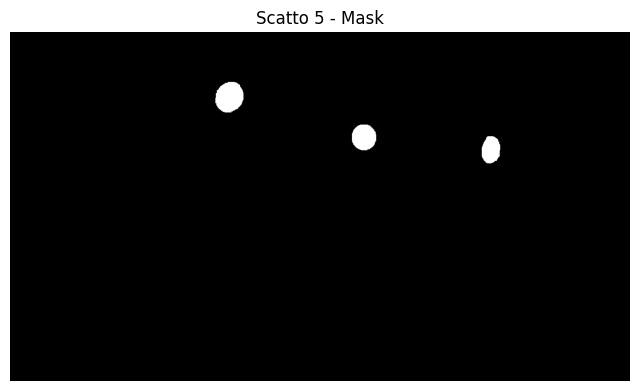


=== ISPEZIONE COMPLETATA ===
Difetti totali prima del filtro duplicati: 10
Difetti univoci dopo filtro duplicati: 8
      Difetto unico 1 rilevato:
        centroid: [827 546]
        pos3d_camera: [ 46.8  41.4 164.9]
        Z camera: 164.9 mm
        radial camera: 62.5 mm
        pos3d_global: [ 45.7 620.3 376.3]
        sph_coord [r, alpha, beta]: [148.9  19.1 106.1]
      Difetto unico 2 rilevato:
        centroid: [552 366]
        pos3d_camera: [-13.7   0.8 148.7]
        Z camera: 148.7 mm
        radial camera: 13.7 mm
        pos3d_global: [-14.8 660.9 392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]
      Difetto unico 3 rilevato:
        centroid: [992 242]
        pos3d_camera: [ 86.9 -28.  170.9]
        Z camera: 170.9 mm
        radial camera: 91.3 mm
        pos3d_global: [-94.3 750.4 333. ]
        sph_coord [r, alpha, beta]: [158.2 -45.4  55.9]
      Difetto unico 4 rilevato:
        centroid: [738  12]
        pos3d_camera: [ 20.9 -61.2 128. ]
       

In [ ]:
all_defects = []

INSPECTION_POSITIONS = [
    [im.INSPECTION_RADIUS,   0, 90],   # alto
    [im.INSPECTION_RADIUS,   0, 45],   # frontale/intermedio
    [im.INSPECTION_RADIUS,   0, 30],   # frontale/intermedio
    [im.INSPECTION_RADIUS,  87, 60],   # laterale destro
    [im.INSPECTION_RADIUS, -87, 60],   # laterale sinistro
]

#INSPECTION_POSITIONS = [[im.INSPECTION_RADIUS, 0, 90]]

# commenta se vuoi usare delle posizoni personalizzate, altrimenti usa quelle di default
# INSPECTION_POSITIONS = im.INSPECTION_POSITIONS

print("=== ISPEZIONE GLOBALE ===")
print(f"Numero posizioni di ispezione: {len(INSPECTION_POSITIONS)}")

im.move_to_hub(controller)

for i, inspection_position in enumerate(INSPECTION_POSITIONS):

    if input(f"\nPremi Invio per eseguire lo scatto in posizione {inspection_position}") != "":
        print("Scatto saltato.")
        continue

    print("\n" + "-" * 60)
    print(f"Scatto {i + 1}/{len(INSPECTION_POSITIONS)}")
    print(f"Posizione sferica: {inspection_position}")

    defect_list, debug_img, mask_bgr, bgr_image = im.point_and_shoot(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        test_sph=inspection_position,
        #insp_radius=im.INSPECTION_RADIUS,           # ora usa la funzione di alpha e beta
        helmet_center=vb.HELMET_CENTER_GLOBAL
    )

    print(f"Difetti trovati in questo scatto: {len(defect_list)}")

    for idx, d in enumerate(defect_list):
        d.say_hi(Name=f"Scatto {i + 1} - difetto {idx + 1}")

    all_defects.extend(defect_list)

    im.show_debug_matplotlib(
        debug_img=debug_img,
        mask_bgr=mask_bgr,
        title=f"Scatto {i + 1}"
    )

print("\n=== ISPEZIONE COMPLETATA ===")
print(f"Difetti totali prima del filtro duplicati: {len(all_defects)}")

unique_defects = im.duplicate_filter(
    all_defects,
    distance_threshold=im.DUPLICATE_DISTANCE
)

print(f"Difetti univoci dopo filtro duplicati: {len(unique_defects)}")


for idx, d in enumerate(unique_defects):
    d.say_hi(Name=f"Difetto unico {idx + 1}")

print("\nRitorno all'hub...")
im.move_to_hub(controller)

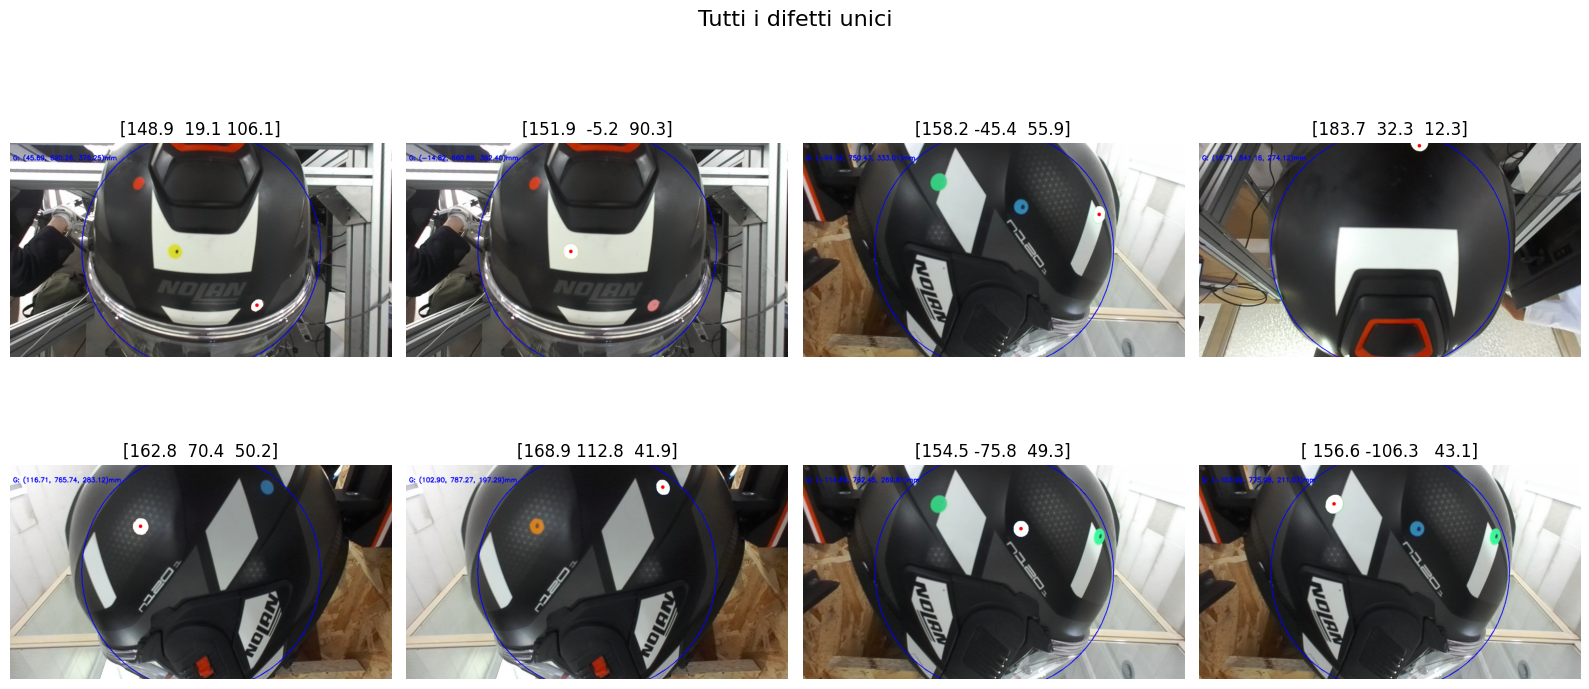

In [7]:
if len(unique_defects) == 0:
    print("Nessun difetto univoco da visualizzare.")
else:
    n_defects = len(unique_defects)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, unique_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti unici", fontsize=16)
    plt.tight_layout()
    plt.show()

## 4 — Raffinamento di ogni difetto

**Attenzione: muove il robot.**

=== RAFFINAMENTO DI TUTTI I DIFETTI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti da raffinare: 8

------------------------------------------------------------
Raffinamento difetto 1/8
      Difetto 1 prima del raffinamento rilevato:
        centroid: [827 546]
        pos3d_camera: [ 46.8  41.4 164.9]
        Z camera: 164.9 mm
        radial camera: 62.5 mm
        pos3d_global: [ 45.7 620.3 376.3]
        sph_coord [r, alpha, beta]: [148.9  19.1 106.1]


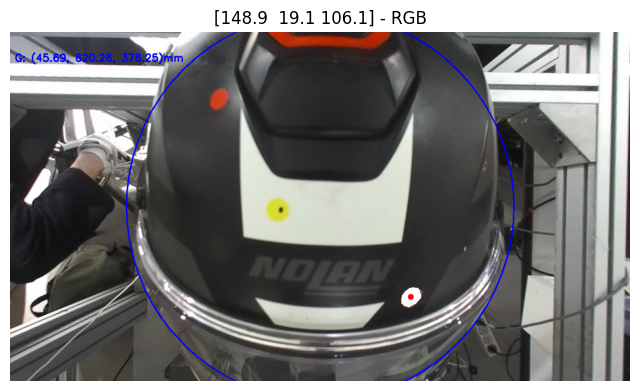

 Raffinamento difetto: r_stimato=148.9mm, alpha=19.1°, beta=106.1°
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (19.1°, 106.1°)
  Movimento camera a r=300mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=149.3 mm, alpha=20.7°, beta=107.3°
  Posizione vecchia: [ 45.7 620.3 376.3] mm
  Posizione nuova:   [ 49.2 617.4 374.5] mm
  Delta: 4.9 mm
Difetto 1 raffinato correttamente.
      Difetto 1 raffinato rilevato:
        centroid: [827 546]
        pos3d_camera: [ 46.8  41.4 164.9]
        Z camera: 164.9 mm
        radial camera: 62.5 mm
        pos3d_global: [ 49.2 617.4 374.5]
        sph_coord [r, alpha, beta]: [148.9  19.1 106.1]

------------------------------------------------------------
Raffinamento difetto 2/8
      Difetto 2 prima del raffinamento rilevato:
        centroid: [552 366]
        pos3d_camera: [-13.7   0.8 148.7]
        Z camera: 148.7 mm
        radial camera: 13.

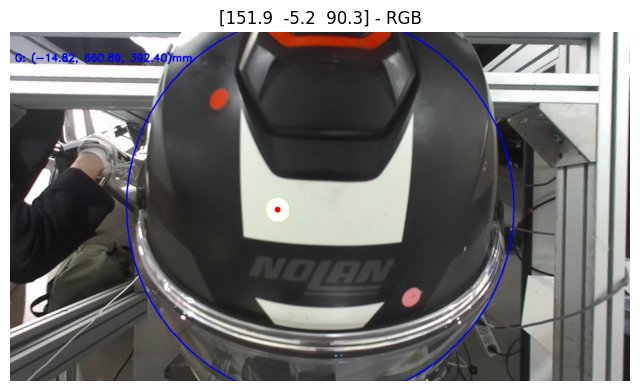

 Raffinamento difetto: r_stimato=151.9mm, alpha=-5.2°, beta=90.3°
  [CIRCLE] Movimento sferico: (19.1°, 106.1°) -> (-5.2°, 90.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=152.2 mm, alpha=-5.5°, beta=90.3°
  Posizione vecchia: [-14.8 660.9 392.4] mm
  Posizione nuova:   [-15.7 660.8 392.6] mm
  Delta: 0.9 mm
Difetto 2 raffinato correttamente.
      Difetto 2 raffinato rilevato:
        centroid: [552 366]
        pos3d_camera: [-13.7   0.8 148.7]
        Z camera: 148.7 mm
        radial camera: 13.7 mm
        pos3d_global: [-15.7 660.8 392.6]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]

------------------------------------------------------------
Raffinamento difetto 3/8
      Difetto 3 prima del raffinamento rilevato:
        centroid: [992 242]
        pos3d_camera: [ 86.9 -28.  170.9]
        Z camera: 170.9 mm
        radial camera: 91.3 

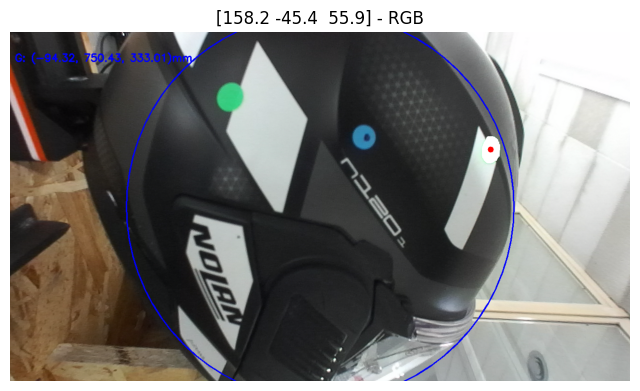

 Raffinamento difetto: r_stimato=158.2mm, alpha=-45.4°, beta=55.9°
  [CIRCLE] Movimento sferico: (-5.2°, 90.3°) -> (-45.4°, 55.9°)
  Movimento camera a r=300mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=158.1 mm, alpha=-42.7°, beta=55.7°
  Posizione vecchia: [-94.3 750.4 333. ] mm
  Posizione nuova:   [-89.7 750.7 337.1] mm
  Delta: 6.2 mm
Difetto 3 raffinato correttamente.
      Difetto 3 raffinato rilevato:
        centroid: [992 242]
        pos3d_camera: [ 86.9 -28.  170.9]
        Z camera: 170.9 mm
        radial camera: 91.3 mm
        pos3d_global: [-89.7 750.7 337.1]
        sph_coord [r, alpha, beta]: [158.2 -45.4  55.9]

------------------------------------------------------------
Raffinamento difetto 4/8
      Difetto 4 prima del raffinamento rilevato:
        centroid: [738  12]
        pos3d_camera: [ 20.9 -61.2 128. ]
        Z camera: 128.0 mm
        radial camera: 64.

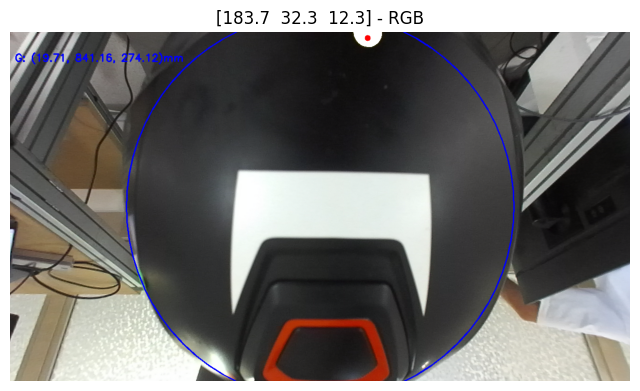

 Raffinamento difetto: r_stimato=183.7mm, alpha=32.3°, beta=12.3°
  [SKIP] Destinazione (alpha=32.3°, beta=12.3°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 4 scartato/non confermato/irraggiungibile.

------------------------------------------------------------
Raffinamento difetto 5/8
      Difetto 5 prima del raffinamento rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.2 144.1]
        Z camera: 144.1 mm
        radial camera: 46.8 mm
        pos3d_global: [116.7 765.7 283.1]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]


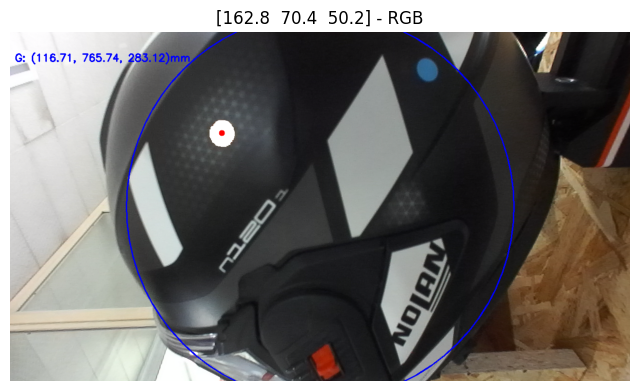

 Raffinamento difetto: r_stimato=162.8mm, alpha=70.4°, beta=50.2°
  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (-45.4°, 55.9°) -> (12.5°, 53.0°)
  [CIRCLE] Movimento sferico: (12.5°, 53.0°) -> (70.4°, 50.2°)
  Movimento camera a r=300mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=162.3 mm, alpha=68.9°, beta=49.9°
  Posizione vecchia: [116.7 765.7 283.1] mm
  Posizione nuova:   [114.6 766.3 285.8] mm
  Delta: 3.4 mm
Difetto 5 raffinato correttamente.
      Difetto 5 raffinato rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.2 144.1]
        Z camera: 144.1 mm
        radial camera: 46.8 mm
        pos3d_global: [114.6 766.3 285.8]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]

------------------------------------------------------------
Raffinamento difetto 6/8
      Difetto 6 prima del raffinamento rilev

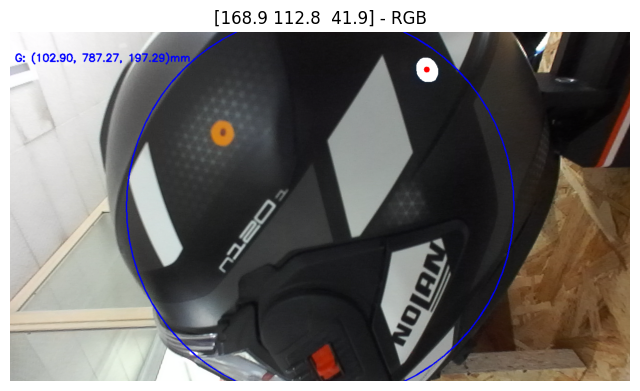

 Raffinamento difetto: r_stimato=168.9mm, alpha=112.8°, beta=41.9°
  [SKIP] Destinazione (alpha=112.8°, beta=41.9°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 6 scartato/non confermato/irraggiungibile.

------------------------------------------------------------
Raffinamento difetto 7/8
      Difetto 7 prima del raffinamento rilevato:
        centroid: [730 216]
        pos3d_camera: [ 22.7 -29.9 150.1]
        Z camera: 150.1 mm
        radial camera: 37.5 mm
        pos3d_global: [-114.7  762.5  269.8]
        sph_coord [r, alpha, beta]: [154.5 -75.8  49.3]


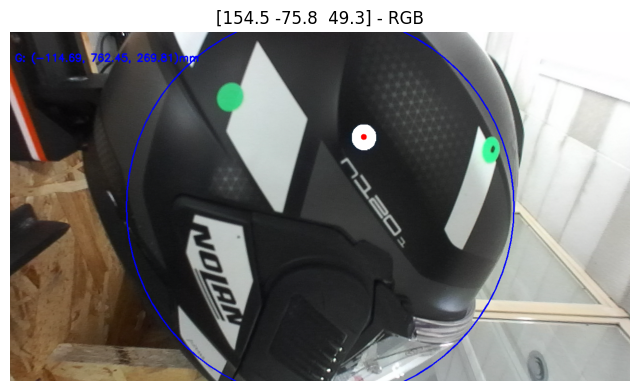

 Raffinamento difetto: r_stimato=154.5mm, alpha=-75.8°, beta=49.3°
  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (70.4°, 50.2°) -> (-2.7°, 49.8°)
  [CIRCLE] Movimento sferico: (-2.7°, 49.8°) -> (-75.8°, 49.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  [REFINE] Sicurezza difetto 10/10, difetto raffinato
  Raffinamento completato.
  Nuove coordinate sferiche:
    r=154.3 mm, alpha=-75.2°, beta=48.5°
  Posizione vecchia: [-114.7  762.5  269.8] mm
  Posizione nuova:   [-112.8  764.   270.6] mm
  Delta: 2.5 mm
Difetto 7 raffinato correttamente.
      Difetto 7 raffinato rilevato:
        centroid: [730 216]
        pos3d_camera: [ 22.7 -29.9 150.1]
        Z camera: 150.1 mm
        radial camera: 37.5 mm
        pos3d_global: [-112.8  764.   270.6]
        sph_coord [r, alpha, beta]: [154.5 -75.8  49.3]

------------------------------------------------------------
Raffinamento difetto 8/8
      Difetto 8 prima del raffina

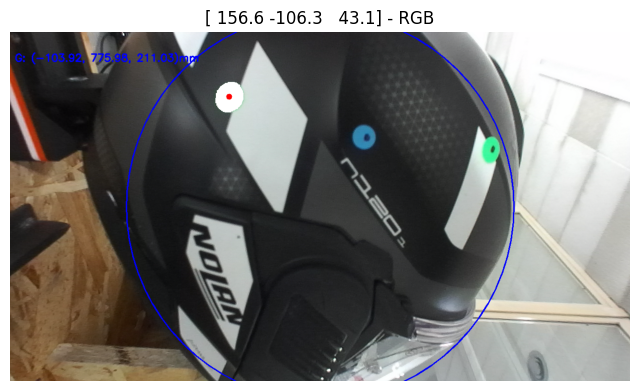

 Raffinamento difetto: r_stimato=156.6mm, alpha=-106.3°, beta=43.1°
  [SKIP] Destinazione (alpha=-106.3°, beta=43.1°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 8 scartato/non confermato/irraggiungibile.


In [8]:
print("=== RAFFINAMENTO DI TUTTI I DIFETTI ===")
im.move_to_hub(controller)

refined_defects = []

print(f"Difetti da raffinare: {len(unique_defects)}")

for i, d in enumerate(unique_defects.copy()):  # Crea una copia per iterare

    print("\n" + "-" * 60)
    print(f"Raffinamento difetto {i + 1}/{len(unique_defects)}")

    d.say_hi(Name=f"Difetto {i + 1} prima del raffinamento")
    im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")

    if input(f"\nPremi Invio per il raffinamento in posizione {np.round(d.sph_coord, 2)}") != "":
        print("raffinamento saltato.")
        continue
    
    success = im.refine_defect_position(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        defect_obj=d,
        helmet_center=vb.HELMET_CENTER_GLOBAL,
        generic_detection=im.GENERIC_DETECTION
    )

    if success:
        print(f"Difetto {i + 1} raffinato correttamente.")
        d.say_hi(Name=f"Difetto {i + 1} raffinato")
        refined_defects.append(d)
    else:
        print(f"Difetto {i + 1} scartato/non confermato/irraggiungibile.")


In [9]:
print("\n=== RAFFINAMENTO COMPLETATO ===")
print(f"Difetti iniziali: {len(unique_defects)}")
print(f"Difetti raffinati/confermati: {len(refined_defects)}")

for i, d in enumerate(refined_defects):
    d.say_hi(Name=f"Difetto raffinato {i + 1}")

print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
print("Robot tornato in posizione iniziale.")


=== RAFFINAMENTO COMPLETATO ===
Difetti iniziali: 8
Difetti raffinati/confermati: 5
      Difetto raffinato 1 rilevato:
        centroid: [827 546]
        pos3d_camera: [ 46.8  41.4 164.9]
        Z camera: 164.9 mm
        radial camera: 62.5 mm
        pos3d_global: [ 49.2 617.4 374.5]
        sph_coord [r, alpha, beta]: [148.9  19.1 106.1]
      Difetto raffinato 2 rilevato:
        centroid: [552 366]
        pos3d_camera: [-13.7   0.8 148.7]
        Z camera: 148.7 mm
        radial camera: 13.7 mm
        pos3d_global: [-15.7 660.8 392.6]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]
      Difetto raffinato 3 rilevato:
        centroid: [992 242]
        pos3d_camera: [ 86.9 -28.  170.9]
        Z camera: 170.9 mm
        radial camera: 91.3 mm
        pos3d_global: [-89.7 750.7 337.1]
        sph_coord [r, alpha, beta]: [158.2 -45.4  55.9]
      Difetto raffinato 4 rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.2 144.1]
        Z camera: 144.1

=== VISUALIZZA TUTTI I DIFETTI RAFFINATI ===


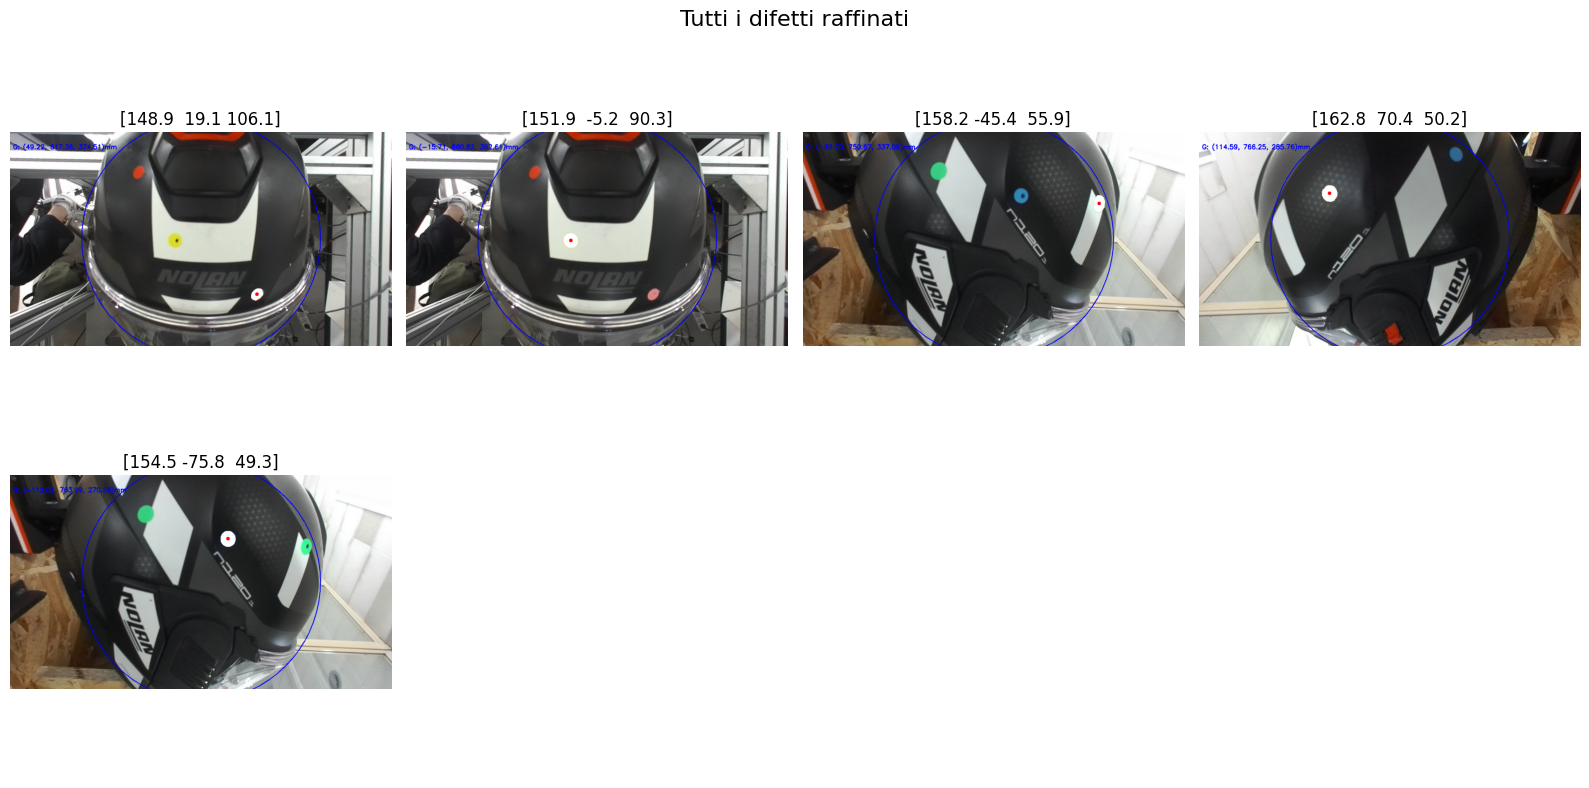

In [10]:
print("=== VISUALIZZA TUTTI I DIFETTI RAFFINATI ===")
if len(refined_defects) == 0:
    print("Nessun difetto raffinato da visualizzare.")
else:
    n_defects = len(refined_defects)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, refined_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti raffinati", fontsize=16)
    plt.tight_layout()
    plt.show()

## 5 — Marcatura di ogni difetto

**Attenzione: muove il robot e prova a marcare con il pennarello.**

=== MARCATURA DI TUTTI I DIFETTI VALIDI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti validi da marcare: 5

------------------------------------------------------------
Marcatura difetto 1/5
      Difetto 1 da marcare rilevato:
        centroid: [827 546]
        pos3d_camera: [ 46.8  41.4 164.9]
        Z camera: 164.9 mm
        radial camera: 62.5 mm
        pos3d_global: [ 49.2 617.4 374.5]
        sph_coord [r, alpha, beta]: [148.9  19.1 106.1]


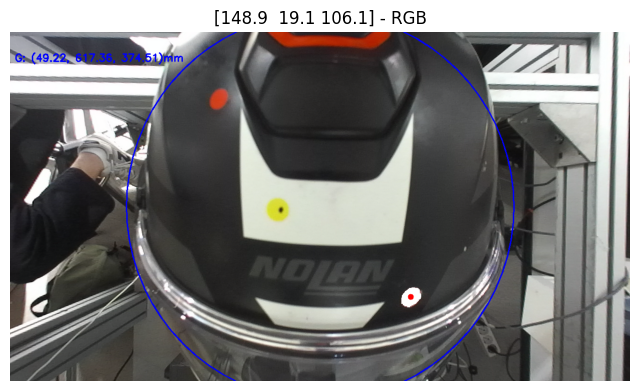

  [CIRCLE] Movimento sferico: (0.0°, 90.0°) -> (19.1°, 106.1°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [ 49.2 617.4 374.5] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [121.7 553.2 595.  160.2  15.2 -95.4]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 1 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 2/5
      Difetto 2 da marcare rilevato:
        centroid: [552 366]
        pos3d_camera: [-13.7   0.8 148.7]
        Z camera: 148.7 mm
        radial camera: 13.7 mm
        pos3d_global: [-15.7 660.8 392.6]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]


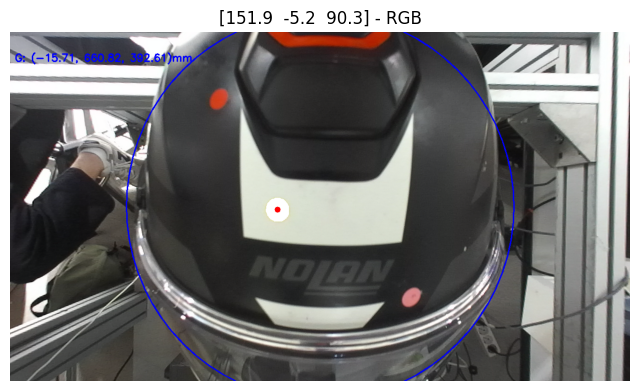

  [CIRCLE] Movimento sferico: (19.1°, 106.1°) -> (-5.2°, 90.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [-15.7 660.8 392.6] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [-3.600e+01  6.597e+02  6.295e+02 -1.748e+02  3.000e-01 -9.000e+01]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 2 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 3/5
      Difetto 3 da marcare rilevato:
        centroid: [992 242]
        pos3d_camera: [ 86.9 -28.  170.9]
        Z camera: 170.9 mm
        radial camera: 91.3 mm
        pos3d_global: [-89.7 750.7 337.1]
        sph_coord [r, alpha, beta]: [158.2 -45.4  55.9]


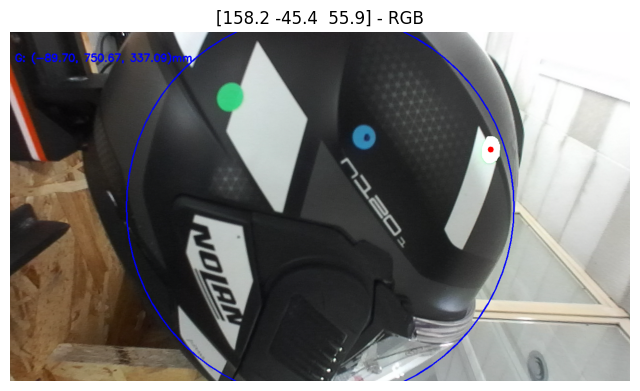

  [CIRCLE] Movimento sferico: (-5.2°, 90.3°) -> (-45.4°, 55.9°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [-89.7 750.7 337.1] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [-230.8  880.6  467.9 -129.2  -23.2 -115.8]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 3 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 4/5
      Difetto 4 da marcare rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.2 144.1]
        Z camera: 144.1 mm
        radial camera: 46.8 mm
        pos3d_global: [114.6 766.3 285.8]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]


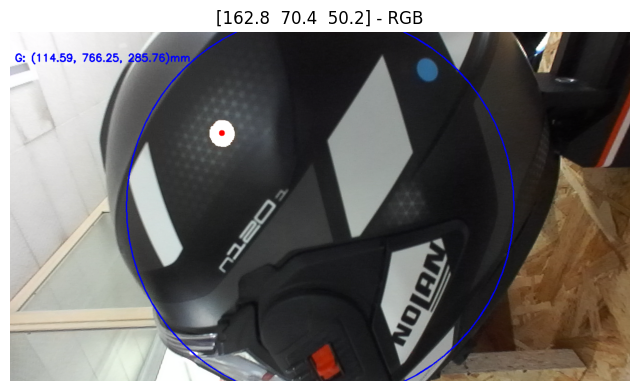

  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (-45.4°, 55.8°) -> (12.5°, 53.0°)
  [CIRCLE] Movimento sferico: (12.5°, 53.0°) -> (70.4°, 50.2°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [114.6 766.3 285.8] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [281.3 911.1 341.6 105.3 -12.4 -51.9]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 4 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 5/5
      Difetto 5 da marcare rilevato:
        centroid: [730 216]
        pos3d_camera: [ 22.7 -29.9 150.1]
        Z camera: 150.1 mm
        radial camera: 37.5 mm
        pos3d_global: [-112.8  764.   270.6]
        sph_coord [r, alpha, beta]: [154.5 -75.8  49.3]


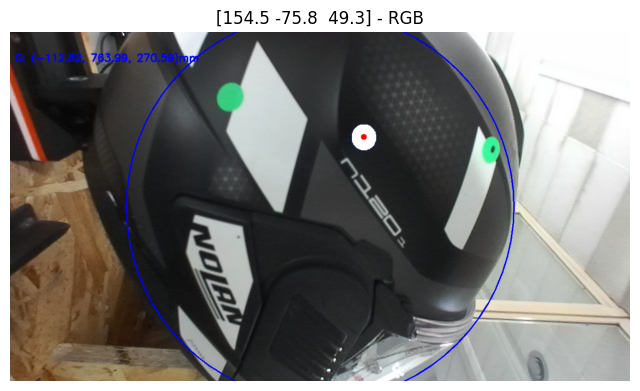

  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (70.4°, 50.2°) -> (-2.7°, 49.8°)
  [CIRCLE] Movimento sferico: (-2.7°, 49.8°) -> (-75.8°, 49.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [-112.8  764.   270.6] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [-287.7  916.1  313.8 -100.9   -9.2 -129.8]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 5 marcato correttamente.

=== MARCATURA COMPLETATA ===
Difetti validi: 5
Difetti marcati: 5

Ritorno alla posizione iniziale...
Ritorno alla posizione di hub [0, 0, 90].
  [CIRCLE] Movimento sferico: (-75.8°, 49.3°) -> (0.0°, 90.0°)
Robot tornato in posizione iniziale.


In [11]:
print("=== MARCATURA DI TUTTI I DIFETTI VALIDI ===")
im.move_to_hub(controller)

# Usa refined_defects se hai fatto la cella di raffinamento.
# Se invece vuoi marcare direttamente quelli dell'ispezione globale, cambia in unique_defects.
valid_defects = refined_defects

print(f"Difetti validi da marcare: {len(valid_defects)}")


marked_defects = []

if not input(f"Premi INVIO per marcare tutti i difetti validi, scrivi nope per annullare: ") == "nope":

    for i, d in enumerate(valid_defects):

        print("\n" + "-" * 60)
        print(f"Marcatura difetto {i + 1}/{len(valid_defects)}")
        d.say_hi(Name=f"Difetto {i + 1} da marcare")
        im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")


        if input(f"\nPremi Invio per marcare il difetto in posizione {np.round(d.sph_coord, 2)}") != "":
            print("Marcatura saltata.")
            continue

        success = im.mark_defect(
            controller=controller,
            defect_obj=d,
            helmet_center=vb.HELMET_CENTER_GLOBAL
        )

        if success:
            print(f"Difetto {i + 1} marcato correttamente.")
            marked_defects.append(d)
        else:
            print(f"Difetto {i + 1} non marcato.")

else:
    print("Marcatura annullata.")

print("\n=== MARCATURA COMPLETATA ===")
print(f"Difetti validi: {len(valid_defects)}")
print(f"Difetti marcati: {len(marked_defects)}")

print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
controller.default_positioning()
print("Robot tornato in posizione iniziale.")